In [25]:
from feos import *
import feos as feos
import si_units as si
import numpy as np
import pandas as pd
from si_units import *
import matplotlib.pyplot as plt

import seaborn as sns
sns.set_context('poster')
sns.set_palette('Dark2')
sns.set_style('ticks')
colors = sns.palettes.color_palette('Dark2', 8)

## Effective Mie Parameters
$$
\frac{\nu^{\text{eff}}(D^*,\nu)}{\nu} =
\frac{1 + \xi_0 C_0(\nu)\,D^* + \xi_1 C_1(\nu)\,D^{*2} + \xi_2 C_2(\nu)\,D^{*3}}
     {1 + \xi_3 C_3(\nu)\,D^* + \xi_4 C_4(\nu)\,D^{*2}}
$$
with $ \xi_0= \xi_3=1$
$$
\frac{\sigma^{\text{eff}}(D^*,\sigma)}{\sigma} =
\frac{1 + \xi_0 C_0(\sigma)\,D^* + \xi_1 C_1(\sigma)\,D^{*2}  + \xi_3 \,D^{*3}}
     {1 + \xi_2 C_2(\sigma)\,D^*+  \xi_4 \,D^{*2}}
$$
with $ \xi_0= \xi_2=1$ and for FH1 $\xi_3=\xi_4=0$
$$
\frac{\varepsilon^{\text{eff}}(D^*,\varepsilon)}{\varepsilon} =
\frac{1 + \xi_0 C_0(\varepsilon)\,D^* + \xi_1 C_1(\varepsilon)\,D^{*2} + \xi_3 \,D^{*3}}
     {1 + \xi_3 C_3(\varepsilon)\,D^*+  \xi_4 \,D^{*2}}
     $$
with $ \xi_0= \xi_2=1$ and for FH1 $\xi_3=\xi_4=0$

## Helium

In [26]:
tc = 5.1953
vle = pd.read_csv("data/helium_data/nist_vle.txt", sep="\t")
vle = vle[vle['Temperature (K)'] < 0.9 * tc][11:]
isotherms = pd.read_csv("data/helium_data/nist_isotherms.txt", sep="\t")

In [27]:
# SAFT-VRQ-Mie
ailo = dict(sigma=2.7443, epsilon_k=5.4195, rep=9, att=6) #, c_sigma=[1.0]*3, c_epsilon_k=[1.0]*3, c_rep=[1.0]*5)
vrqmie_ailo = dict(m=1.0, sigma=2.7443, epsilon_k=5.4195, lr=9, la=6, fh=1)
vrq_pr = PureRecord(identifier=Identifier("helium"), molarweight=4.002602, **vrqmie_ailo)
vrq_model = EquationOfState.saftvrqmie(Parameters.new_pure(vrq_pr))

#vle_vrq = PhaseDiagram.pure(vrq_model, 2.5*KELVIN, 100)
df_vrq = PhaseDiagram.pure(vrq_model, min_temperature=2*si.KELVIN, npoints=250).to_dict(feos.Contributions.Residual)

In [28]:
# uv-CS with optimized parameters
thijs = dict(
    sigma=2.6953,
    epsilon_k=5.2850,
    rep=8.2761,
    att=6.0,
    c_sigma=[4.1529, 17.130, 4.6523, 0, 0],
    c_epsilon_k=[0.25290, 0.0, 0.42998, 0, 0],
    c_rep=[0.88165, 1.0523, 2.7524, 0.97560, 0.82524]
)
pr = feos.PureRecord(identifier=feos.Identifier("helium"), molarweight=4.002602, **thijs)
cs_model = feos.EquationOfState.uvcstheory(feos.Parameters.new_pure(pr))
df_cs = feos.PhaseDiagram.pure(cs_model, min_temperature=2*si.KELVIN, npoints=250).to_dict(feos.Contributions.Residual)

In [124]:
# SAFT-VR CS


vrcs_pars = dict(
    m=1.0, sigma=2.674056, epsilon_k=9.466831, lr=11.981772, la=6.0,
    c_sigma=[0.311121, -1.729471, 0.228738, -0.000129, 0.001391],
    c_epsilon_k=[-0.152164, 0.401943, 0.262577, 0.147911, 0.001790],
    c_lr=[-0.265675, 0.183267, 2.577499, -0.376193, 0.660750],
)
vrcs_pr = feos.PureRecord(identifier=feos.Identifier("helium"), molarweight=4.002602, **vrcs_pars)


#vle_vrq = PhaseDiagram.pure(vrq_model, 2.5*KELVIN, 100)
df_vrcs = PhaseDiagram.pure(vrcs_model, min_temperature=2*si.KELVIN, npoints=250).to_dict(feos.Contributions.Residual)

In [125]:
# Fitted with feos/examples/uvcs/helium_adjustment.py (15-parameter version):
# all 5 slots [xi0..xi4] of c_sigma, c_epsilon_k, and c_rep are free (unlike
# earlier versions that fixed xi0=xi2=1) - a strict superset of Thijs's own
# parameterization, since xi0/xi1/xi2 all carry a genuine C_i(m) polynomial
# prefactor and are directly comparable in scale to Thijs's fitted values.
#
# Objective (scipy.optimize.least_squares, method="trf"): relative residuals
# on NIST sub-critical VLE liquid density (2x weight), vapor density, and
# vapor pressure; isotherm density; and the critical point (Tc, p_c
# extrapolated from the NIST table's highest-T rows) - each group scaled by
# 1/sqrt(n_group). Vapor density is now fit directly (previous versions only
# fit liquid density + pressure, leaving vapor density emergent/unfit).
#
# Two regularization terms keep the extra freedom
#   - L2 penalty pulling only the six bare-D*^2 slots (xi3, xi4 of each
#     property - the ones with no C_i(m) prefactor
#     values ~10-100 just to matter) back toward 0.
#   - A low-D* anchor: below D*(Tc) (~0.027 for helium) there's no VLE or
#     isotherm data at all - real helium doesn't exist there - so nothing
#     constrains the fit's shape in that region. Added residuals comparing
#     effective_sigma/effective_epsilon_k/effective_rep_ratio under the
#     fitted coefficients against the literature F
#     points between 0 and D*(Tc) (weight 0.3), so the fit stays anchored to
#     FH1 in the high-temperature extrapolation region instead of drifting.
#
# Result: success=True, status=2 (genuine convergence, not nfev cutoff),
# nfev=82, cost=0.000133 - best of any version tri
# NIST on p_sat (0.63% vs. 1.46%) and rho_liq (0.14% vs. 0.77%); ties on
# rho_vap (0.58% vs. 0.55%) and isotherm rho (0.58% vs. 0.54%). The
# bare-D*^2 slots (index 3, 4) settled near zero on their own even without
# heavy regularization - the extra freedom was used in xi0/xi1/xi2 instead.
_c_sigma_new = [5.025695, 25.562637, 5.706179, -0.000001, 0.000108]
_c_epsilon_new = [-0.318478, 1.679350, 0.112019, -0.000000, -0.000362]
_c_rep_new = [0.188398, -0.252129, 2.209865, 0.094255, -0.208037]

In [126]:
# new Fit: 
# Fitted with feos/examples/uvcs/helium_adjustment.py, following the same
# 5-slot Feynman-Hibbs-1 "new Ansatz" structure as Helium_Parameters.ipynb:
# base Mie potential (sigma, epsilon_k, rep, att) fixed at Thijs's values,
# c_sigma/c_epsilon_k/c_rep = [xi0, xi1, xi2, xi3, xi4] with xi0 = xi2 = 1
# fixed, xi1/xi3/xi4 free (9 free parameters total).
#
# Objective (scipy.optimize.least_squares, method="trf"): relative residuals
# on NIST sub-critical VLE liquid density (2x weight) + vapor pressure,
# isotherm density, and the critical point (Tc, p_c extrapolated from the
# NIST table's highest-T rows) - each group scaled by 1/sqrt(n_group).
#
# xi3/xi4 multiply a *bare* D*^2 term with no C_i(m) polynomial prefactor
# (unlike every other slot), so they only matter at values ~10-100 given
# D* <~ 0.05 for helium - an unregularized fit pins them at whatever bounds
# you set (tried (-8,8) and (-100,100), both hit the wall for ~1.6-1.8e-4
# cost). Added an L2 penalty pulling every free parameter back toward its
# "no correction" default (1 for xi1 slots, 0 for the bare xi3/xi4 slots),
# reg_lambda=0.01, group-scaled like the other residuals. Under that penalty
# xi3/xi4 settle near 0 on their own - the bare-D*^2 terms just don't earn
# their keep against this data - leaving an interior optimum instead of a
# pinned one, at a small cost trade-off (0.000209 vs. ~0.00016-0.00018
# unregularized).
#
# least_squares: success=True, cost=0.000209, bounds=(-50, 50) (safety net
# only, not binding).

_c_sigma_new=[1, 1.16387818, 1, 0.01285522, -0.02988660]
_c_epsilon_new=[1, -0.83319509, 1, -0.01493214, 0.00954725]
_c_rep_new=[1, 0.72161393, 1, 1.22928652, 0.22721909]

anja = dict(
    sigma=2.6953,
    epsilon_k=5.2850,
    rep=8.2761,
    att=6.0,
    c_sigma= _c_sigma_new,#[1, 1.16387818, 1, 0.01285522, -0.02988660],
    c_epsilon_k=_c_epsilon_new,#[1, -0.83319509, 1, -0.01493214, 0.00954725],
    c_rep=_c_rep_new,#[1, 0.72161393, 1, 1.22928652, 0.22721909],
)
pr = feos.PureRecord(identifier=feos.Identifier("helium"), molarweight=4.002602, **anja)
cs_model_new = feos.EquationOfState.uvcstheory(feos.Parameters.new_pure(pr))
df_cs_new = feos.PhaseDiagram.pure(cs_model_new, min_temperature=2*si.KELVIN, npoints=250).to_dict(feos.Contributions.Residual)

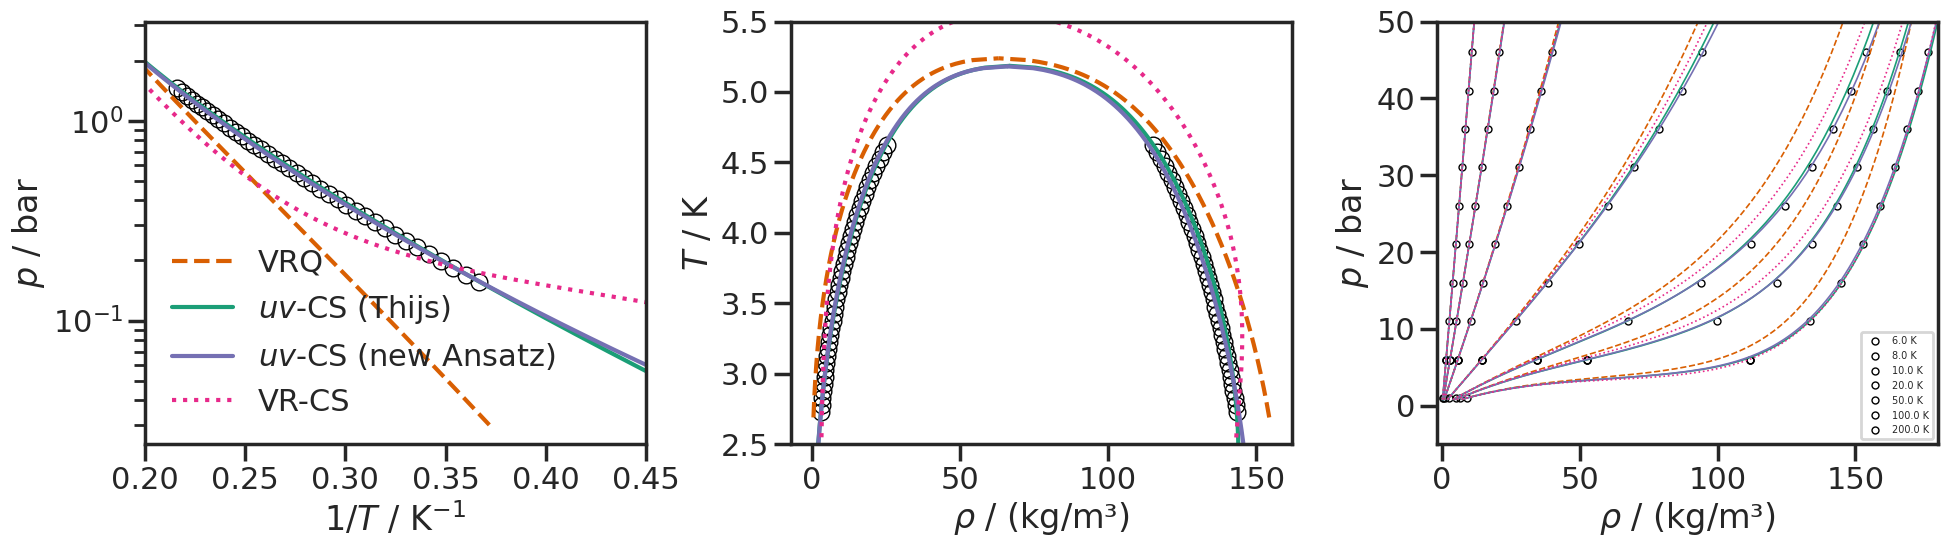

In [127]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- Subplot 1: Vapor pressure vs Temperature  ---
axes[0].plot(1/ vle['Temperature (K)'], vle['Pressure (MPa)'] * (MEGA*PASCAL/BAR), 'o', mec='k', mfc='None')
axes[0].set_xlabel('$1/T$ / K$^{-1}$')
axes[0].set_ylabel('$p$ / bar')
#axes[0].set_title('Vapor Pressure')
axes[0].set_yscale('log')
axes[0].plot(1/np.array(df_vrq["temperature"]), np.array(df_vrq["pressure"]) * (PASCAL/BAR), '--', color=colors[1], label="VRQ")
axes[0].plot(1/np.array(df_cs["temperature"]), np.array(df_cs["pressure"]) * (PASCAL/BAR),  color=colors[0], label="$uv$-CS (Thijs)")
axes[0].plot(1/np.array(df_cs_new["temperature"]), np.array(df_cs_new["pressure"]) * (PASCAL/BAR),  color=colors[2], label="$uv$-CS (new Ansatz)")
axes[0].plot(1/np.array(df_vrcs["temperature"]), np.array(df_vrcs["pressure"]) * (PASCAL/BAR), ':', color=colors[3], label="VR-CS")
axes[0].set_xlim(0.2, 0.45)





# --- Subplot 2: Density vs Temperature---
axes[1].plot(vle["Density (l, kg/m3)"], vle['Temperature (K)'], "o", mec='k', mfc='None')
axes[1].plot(vle["Density (v, kg/m3)"], vle['Temperature (K)'], 'o', mec='k', mfc='None')
axes[1].set_xlabel('$\\rho$ / (kg/m³)')
axes[1].set_ylabel('$T$ / K')
axes[1].set_ylim(2.5, 5.5)
axes[1].plot(df_vrq["mass density liquid"], df_vrq["temperature"],'--', color=colors[1], label="VRQ")
axes[1].plot(df_vrq["mass density vapor"], df_vrq["temperature"], '--', color=colors[1] )


axes[1].plot(df_cs["mass density liquid"], df_cs["temperature"],'-', color=colors[0], label="$uv$-CS")
axes[1].plot(df_cs["mass density vapor"], df_cs["temperature"], '-', color=colors[0] )

axes[1].plot(df_cs_new["mass density liquid"], df_cs_new["temperature"],'-', color=colors[2], label="$uv$-CS (new Ansatz)")
axes[1].plot(df_cs_new["mass density vapor"], df_cs_new["temperature"], '-', color=colors[2] )

axes[1].plot(df_vrcs["mass density liquid"], df_vrcs["temperature"],':', color=colors[3], label="VR-CS")
axes[1].plot(df_vrcs["mass density vapor"], df_vrcs["temperature"], ':', color=colors[3] )



axes[0].legend(loc='best', frameon=False)

#axes[1].set_title('VLE Envelope')

# --- Subplot 3: Pressure vs Density (isotherms) ---
for temp, group in isotherms.groupby('Temperature (K)'):
    axes[2].plot(group['Density (l, kg/m3)'],np.array( group['Pressure (MPa)']) * (MEGA*PASCAL)/BAR,
                 'o', mec='k', mfc='None', ms=5, label=f'{temp} K')
axes[2].set_xlabel('$\\rho$ / (kg/m³)')
axes[2].set_ylabel('$p$ / bar')
axes[2].legend(fontsize=7, loc='best')
axes[2].set_ylim(-5,50)
axes[2].set_xlim(-2, 180)


# --- Add theory isotherms ---
isotherm_temps = isotherms['Temperature (K)'].unique()

for i, temp in enumerate(sorted(isotherm_temps)):
    color = colors[i % len(colors)]  # cycle through your color list

    rho_min = isotherms[isotherms['Temperature (K)'] == temp]['Density (l, kg/m3)'].min()
    rho_max = isotherms[isotherms['Temperature (K)'] == temp]['Density (l, kg/m3)'].max()
    densities = np.linspace(rho_min * 0.8, rho_max * 1.2, 200)

    pressures = []
    valid_densities = []
    pressures_vrq = []
    pressures_cs_new = []
    pressures_vrcs = []
    for rho in densities:
        try:
            state = feos.State(
                cs_model,
                temperature=temp * si.KELVIN,
                density=(rho / 4.002602) * si.MOL / si.METER**3 * 1000  # kg/m³ → mol/m³
            )
            p = state.pressure(feos.Contributions.Residual) / BAR
            pig = (rho / 4.002602) * si.MOL / si.METER**3 * 1000 * RGAS * temp * KELVIN
            #print(pig / BAR)
            pressures.append(p + pig/BAR)
            
            state = feos.State(
                cs_model_new,
                temperature=temp * si.KELVIN,
                density=(rho / 4.002602) * si.MOL / si.METER**3 * 1000  # kg/m³ → mol/m³
            )
            p = state.pressure(feos.Contributions.Residual) / BAR
            #pig = (rho / 4.002602) * si.MOL / si.METER**3 * 1000 * RGAS * temp * KELVIN
            #print(pig / BAR)
            pressures_cs_new.append(p + pig/BAR)
            
            
            
            state = feos.State(
                vrq_model,
                temperature=temp * si.KELVIN,
                density=(rho / 4.002602) * si.MOL / si.METER**3 * 1000  # kg/m³ → mol/m³
            )
            p = state.pressure(feos.Contributions.Residual) / BAR
            pressures_vrq.append(p + pig/BAR)
            
            
            
            state = feos.State(
                vrcs_model,
                temperature=temp * si.KELVIN,
                density=(rho / 4.002602) * si.MOL / si.METER**3 * 1000  # kg/m³ → mol/m³
            )
            p = state.pressure(feos.Contributions.Residual) / BAR
            pressures_vrcs.append(p + pig/BAR)
            
            
            
            valid_densities.append(rho)
        except Exception:
            continue

    if valid_densities:
        axes[2].plot(valid_densities, pressures, '-',lw=1.2, color=colors[0] )
        axes[2].plot(valid_densities, pressures_vrq, '--',lw=1.2, color=colors[1] )
        axes[2].plot(valid_densities, pressures_cs_new, '-',lw=1.2, color=colors[2] )
        axes[2].plot(valid_densities, pressures_vrcs, ':',lw=1.2, color=colors[3] )
plt.tight_layout()
plt.show()

## Evaluate effective parameters

In [128]:
_C = [
    [-1.0577620680e02, 2.7130516920e01, -7.9885048560e-02],
    [-2.2875719760e03, 5.1995559760e02, 8.2111050000e-01],
    [1.7306319200e03, -1.7476174200e02, 3.2561549200e01],
    [-9.0993639000e01, 2.2823545260e01, -2.8168749280e-02],
    [-1.4764571200e03, 4.3447760860e02, -1.1267359060e01],
]
_CS = [
    31.60144413, 2.09612861, 0.20116118,
    50.80286701, -4.28014515, 0.20063555,
    25.11333946, 1.35310377, 0.20250069,
]
_CE = [
    10.60837315, 1.58987996, 0.19807347,
    17.92633472, -19.76493004, 3.91514157,
    7.17199935, 6.45489122, 0.18773935,
]

def effective_rep_ratio(qd, m, c_scale=None):
    c_scale = c_scale if c_scale is not None else [1.0] * 5
    pref = [(_C[i][0] + m * (_C[i][1] + m * _C[i][2])) * c_scale[i] for i in range(5)]
    num = qd * (qd * (qd * pref[2] + pref[1]) + pref[0]) + 1.0
    den = qd * (qd * pref[4] + pref[3]) + 1.0
    return num / den

def effective_sigma(qd, m, c_scale=None):
    c_scale = c_scale if c_scale is not None else [1.0, 1.0, 1.0, 0.0, 0.0]
    c0 = _CS[0] + m * (_CS[1] + m * _CS[2])
    c1 = _CS[3] + m * (_CS[4] + m * _CS[5])
    c2 = _CS[6] + m * (_CS[7] + m * _CS[8])
    num = qd * (qd * c1 * c_scale[1] + c0 * c_scale[0] + qd**2 * c_scale[3]) + 1.0
    den = qd * c2 * c_scale[2] + qd**2 * c_scale[4] + 1.0
    return num / den

def effective_epsilon_k(qd, m, c_scale=None):
    c_scale = c_scale if c_scale is not None else [1.0, 1.0, 1.0, 0.0, 0.0]
    c0 = _CE[0] + m * (_CE[1] + m * _CE[2])
    c1 = _CE[3] + m * (_CE[4] + m * _CE[5])
    c2 = _CE[6] + m * (_CE[7] + m * _CE[8])
    num = qd * (qd * c1 * c_scale[1] + c0 * c_scale[0]) + qd**2 * c_scale[3] + 1.0
    den = qd * c2 * c_scale[2] + qd**2 * c_scale[4] + 1.0
    return num / den

In [129]:
d_star = np.linspace(0.0, 0.05, 200)


_rep=8.2761
    
    
# "Unfitted": c_scale = 1 on every slot that multiplies a genuine C_i(m)
# polynomial, 0 on the slots that only add a bare qd**2 term with no such
# polynomial (slots 3, 4 of sigma/epsilon). This is the literature FH1
# formula with no correction applied — feos's own default when c_sigma /
# c_epsilon_k / c_rep are left as None. For c_rep, all 5 slots have a
# C_i(m) polynomial (the `C` table), so its unfitted vector is all ones.
_c_sigma_unfitted = [1, 1, 1, 0, 0]
_c_epsilon_unfitted = [1, 1, 1, 0, 0]
_c_rep_unfitted = [1, 1, 1, 1, 1]


_c_sigma_thijs=[4.1529, 17.130, 4.6523, 0, 0]
_c_epsilon_thijs=[0.25290, 0.0, 0.42998, 0, 0]
_c_rep_thijs=[0.88165, 1.0523, 2.7524, 0.97560, 0.82524]
    

    
#_c_sigma_new = [1, popt.x[0], 1, popt.x[5], popt.x[6]]
#_c_epsilon_new = [1, popt.x[1], 1, popt.x[7], popt.x[8]]
#_c_rep_new = [1, popt.x[2], 1, popt.x[3], popt.x[4]]

sigma_ratio_unfitted = effective_sigma(d_star, _rep, _c_sigma_unfitted)
epsilon_ratio_unfitted = effective_epsilon_k(d_star, _rep, _c_epsilon_unfitted)
rep_ratio_unfitted = effective_rep_ratio(d_star, _rep, _c_rep_unfitted)

sigma_ratio_thijs = effective_sigma(d_star, _rep, _c_sigma_thijs)
epsilon_ratio_thijs = effective_epsilon_k(d_star, _rep, _c_epsilon_thijs)
rep_ratio_thijs = effective_rep_ratio(d_star, _rep, _c_rep_thijs)

sigma_ratio_new = effective_sigma(d_star, _rep, _c_sigma_new)
epsilon_ratio_new = effective_epsilon_k(d_star, _rep, _c_epsilon_new)
rep_ratio_new = effective_rep_ratio(d_star, _rep, _c_rep_new)

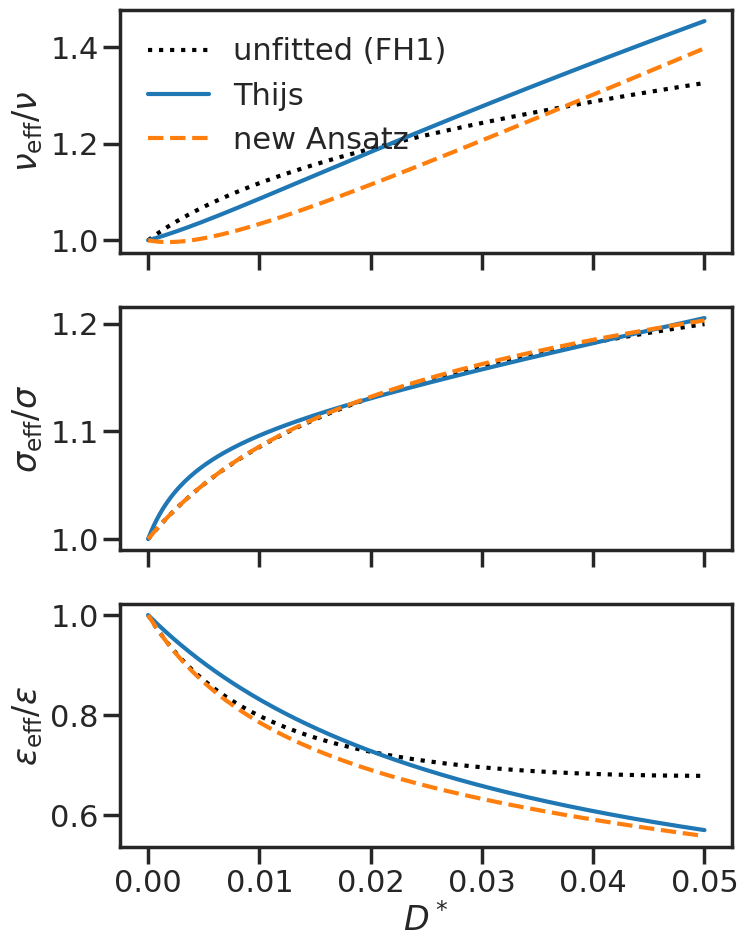

In [130]:
fig2, axes2 = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

axes2[0].plot(d_star, rep_ratio_unfitted, ":", color="k", label="unfitted (FH1)")
axes2[0].plot(d_star, rep_ratio_thijs, "-", color="tab:blue", label="Thijs")
axes2[0].plot(d_star, rep_ratio_new, "--", color="tab:orange", label="new Ansatz")
axes2[0].set_ylabel(r"$\nu_\mathrm{eff}/\nu$")
axes2[0].legend(frameon=False)

axes2[1].plot(d_star, sigma_ratio_unfitted, ":", color="k")
axes2[1].plot(d_star, sigma_ratio_thijs, "-", color="tab:blue")
axes2[1].plot(d_star, sigma_ratio_new, "--", color="tab:orange")
axes2[1].set_ylabel(r"$\sigma_\mathrm{eff}/\sigma$")

axes2[2].plot(d_star, epsilon_ratio_unfitted, ":", color="k")
axes2[2].plot(d_star, epsilon_ratio_thijs, "-", color="tab:blue")
axes2[2].plot(d_star, epsilon_ratio_new, "--", color="tab:orange")
axes2[2].set_ylabel(r"$\varepsilon_\mathrm{eff}/\varepsilon$")
axes2[2].set_xlabel("$D^*$")

plt.tight_layout()


## MARD vs. NIST data

Mean Absolute Relative Deviation, in %, between each model and the NIST
tables above: `mard_vle` interpolates the model's `PhaseDiagram.pure` output
(`df_vrq`/`df_cs`/`df_cs_new`) onto the NIST VLE temperature grid and compares
vapor pressure / liquid density / vapor density there; `mard_isotherms`
evaluates the EOS directly at each experimental isotherm `(T, p)` point
(single-phase `feos.State`, not a saturation point) and compares density.

In [131]:
def mard_vle(df_model, model_col, nist_col, unit_factor=1.0):
    """Mean absolute relative deviation (%) of a VLE quantity vs. NIST,
    interpolating the model's PhaseDiagram.pure output onto the NIST
    temperature grid."""
    order = np.argsort(df_model["temperature"])
    t_model = np.array(df_model["temperature"])[order]
    y_model = np.array(df_model[model_col])[order] * unit_factor

    t_nist = vle["Temperature (K)"].to_numpy()
    y_nist = vle[nist_col].to_numpy()

    mask = (t_nist >= t_model.min()) & (t_nist <= t_model.max())
    y_interp = np.interp(t_nist[mask], t_model, y_model)
    return 100 * np.mean(np.abs((y_interp - y_nist[mask]) / y_nist[mask]))


def mard_isotherms(eos, molarweight=4.002602):
    """Mean absolute relative deviation (%) of isotherm density vs. NIST,
    evaluating the EOS directly at each experimental (T, p) point."""
    errs = []
    for _, row in isotherms.iterrows():
        try:
            state = feos.State(
                eos,
                temperature=row["Temperature (K)"] * si.KELVIN,
                pressure=row["Pressure (MPa)"] * si.MEGA * si.PASCAL,
            )
            rho_model = state.mass_density() / (si.KILOGRAM / si.METER**3)
            rho_nist = row["Density (l, kg/m3)"]
            errs.append(abs(rho_model - rho_nist) / rho_nist)
        except Exception:
            continue
    return 100 * np.mean(errs)

In [132]:
mard_table = pd.DataFrame([
    dict(
        model="VRQ-Mie",
        MARD_psat=mard_vle(df_vrq, "pressure", "Pressure (MPa)", unit_factor=1e-6),
        MARD_rho_liq=mard_vle(df_vrq, "mass density liquid", "Density (l, kg/m3)"),
        MARD_rho_vap=mard_vle(df_vrq, "mass density vapor", "Density (v, kg/m3)"),
        MARD_isotherm_rho=mard_isotherms(vrq_model),
    ),
    dict(
        model="uv-CS (Thijs)",
        MARD_psat=mard_vle(df_cs, "pressure", "Pressure (MPa)", unit_factor=1e-6),
        MARD_rho_liq=mard_vle(df_cs, "mass density liquid", "Density (l, kg/m3)"),
        MARD_rho_vap=mard_vle(df_cs, "mass density vapor", "Density (v, kg/m3)"),
        MARD_isotherm_rho=mard_isotherms(cs_model),
    ),
    dict(
        model="uv-CS (new Ansatz)",
        MARD_psat=mard_vle(df_cs_new, "pressure", "Pressure (MPa)", unit_factor=1e-6),
        MARD_rho_liq=mard_vle(df_cs_new, "mass density liquid", "Density (l, kg/m3)"),
        MARD_rho_vap=mard_vle(df_cs_new, "mass density vapor", "Density (v, kg/m3)"),
        MARD_isotherm_rho=mard_isotherms(cs_model_new),
    ),
])
mard_table

,model,MARD_psat,MARD_rho_liq,MARD_rho_vap,MARD_isotherm_rho
0,VRQ-Mie,44.448612,6.325924,50.598697,3.831399
1,uv-CS (Thijs),1.455006,0.774984,0.550006,0.537306
2,uv-CS (new Ansatz),0.558567,0.388790,1.893149,1.211987


In [112]:
mard_table = pd.DataFrame([
    dict(
        model="VRQ-Mie",
        MARD_psat=mard_vle(df_vrq, "pressure", "Pressure (MPa)", unit_factor=1e-6),
        MARD_rho_liq=mard_vle(df_vrq, "mass density liquid", "Density (l, kg/m3)"),
        MARD_rho_vap=mard_vle(df_vrq, "mass density vapor", "Density (v, kg/m3)"),
        MARD_isotherm_rho=mard_isotherms(vrq_model),
    ),
    dict(
        model="uv-CS (Thijs)",
        MARD_psat=mard_vle(df_cs, "pressure", "Pressure (MPa)", unit_factor=1e-6),
        MARD_rho_liq=mard_vle(df_cs, "mass density liquid", "Density (l, kg/m3)"),
        MARD_rho_vap=mard_vle(df_cs, "mass density vapor", "Density (v, kg/m3)"),
        MARD_isotherm_rho=mard_isotherms(cs_model),
    ),
    dict(
        model="uv-CS (new Ansatz)",
        MARD_psat=mard_vle(df_cs_new, "pressure", "Pressure (MPa)", unit_factor=1e-6),
        MARD_rho_liq=mard_vle(df_cs_new, "mass density liquid", "Density (l, kg/m3)"),
        MARD_rho_vap=mard_vle(df_cs_new, "mass density vapor", "Density (v, kg/m3)"),
        MARD_isotherm_rho=mard_isotherms(cs_model_new),
    ),
])
mard_table

,model,MARD_psat,MARD_rho_liq,MARD_rho_vap,MARD_isotherm_rho
0,VRQ-Mie,44.448612,6.325924,50.598697,3.831399
1,uv-CS (Thijs),1.455006,0.774984,0.550006,0.537306
2,uv-CS (new Ansatz),0.558567,0.388790,1.893149,1.211987
